# Assignment #
## Andres Arias
### Z23987588

## 1. Load datasets in csv format
### Edges

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random

# I'm using this path because I have the data in my local machine amd working with VS Code, you can change it to your own path
path_1 = '/Users/andresarias/Documents/FAU/SocialNetworks_BigData/Assignment_1/data/edges.csv'
edges = pd.read_csv(path_1, sep=',')
edges.head(5)

,id_0,id_1
0,76M2Ekj8bG8W7X2nbx2CpF,7sfl4Xt5KmfyDs2T3SVSMK
1,0hk4xVujcyOr6USD95wcWb,7Do8se3ZoaVqUt3woqqSrD
2,38jpuy3yt3QIxQ8Fn1HTeJ,4csQIMQm6vI2A2SCVDuM2z
3,6PvcxssrQ0QaJVaBWHD07l,6UCQYrcJ6wab6gnQ89OJFh
4,2R1QrQqWuw3IjoP5dXRFjt,4mk1ScvOUkuQzzCZpT6bc0


### Nodes

In [4]:
path_2 = '/Users/andresarias/Documents/FAU/SocialNetworks_BigData/Assignment_1/data/nodes.csv'
nodes = pd.read_csv(path_2, sep=',')
nodes.head(5)

,spotify_id,name,followers,popularity,genres,chart_hits
0,48WvrUGoijadXXCsGocwM4,Byklubben,1738.0,24,"['nordic house', 'russelater']",['no (3)']
1,4lDiJcOJ2GLCK6p9q5BgfK,Kontra K,1999676.0,72,"['christlicher rap', 'german hip hop']","['at (44)', 'de (111)', 'lu (22)', 'ch (31)', ..."
2,652XIvIBNGg3C0KIGEJWit,Maxim,34596.0,36,[],['de (1)']
3,3dXC1YPbnQPsfHPVkm1ipj,Christopher Martin,249233.0,52,"['dancehall', 'lovers rock', 'modern reggae', ...","['at (1)', 'de (1)']"
4,74terC9ol9zMo8rfzhSOiG,Jakob Hellman,21193.0,39,"['classic swedish pop', 'norrbotten indie', 's...",['se (6)']


## Creating the graph

In [5]:
G = nx.from_pandas_edgelist(edges, source='id_0', target='id_1')
print(G)

Graph with 153327 nodes and 300386 edges


# 2. Visualize the graph

In [6]:
# Choosing a random node to start
random.seed(42)
start_node = random.choice(list(G.nodes))

# I selected BFS for my assignment
bfs_tree = nx.bfs_tree(G, source=start_node)

# Sample of 5k first nodes from the BFS tree
sample_nodes = list(bfs_tree.nodes)[:5000]

# Creating the subgraph with the sampled nodes
G_sample = G.subgraph(sample_nodes).copy()

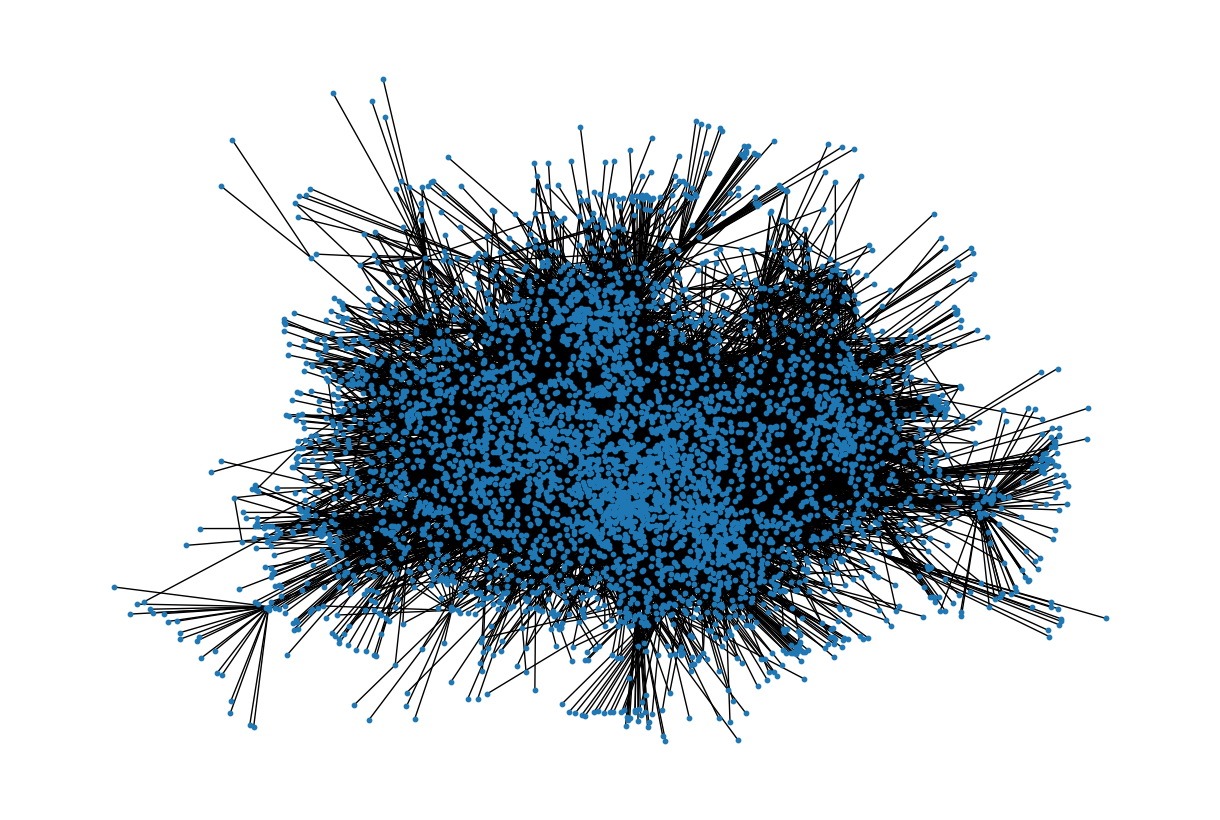

In [7]:
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_sample, seed=42)
nx.draw(G_sample, pos, node_size=10, with_labels=False)
plt.show()

# 3 & 4	Calculate the number of nodes and edges in the graph


In [8]:
print("Initial node", start_node)
print("Nodes:", G_sample.number_of_nodes())
print("Edges", G_sample.number_of_edges())

Initial node 2Z1nXVYB6tke5IsWSLI7lw
Nodes: 5000
Edges 22836


# 5. Calculate the network diameter

In [9]:
# Biggest shortest path length between any two nodes
diameter = nx.diameter(G_sample)
print("Network diameter:", diameter)

Network diameter: 6


# 6. Add a markdown cell. In your own words, interpret the meaning of the obtained value for network diameter

The diameter shows the largest path among the shortest path between all nodes within the network. For my case I have a subgraph with 5000 nodes and my diameter with this seed is 6. It means, even for the two nodes that are farthest apart in the network, the shortest path between them requires at most 6 edges. Therefore, the nodes in this subgraph are relatively close to each other in terms of network connections.

# 7. Plot a histogram representing degree distribution

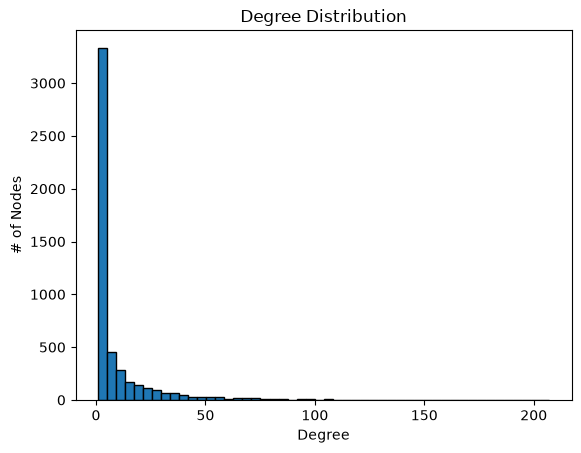

In [10]:
# Degree distribution, using a list comprehension to get the degree of each node in the sampled graph
degrees = [degree for node, degree in G_sample.degree()]

# Plotting the degree distribution
plt.hist(degrees, bins=50, edgecolor='black') #Adjusting bins to 50 for better visualization - distribution of degrees
plt.xlabel("Degree") 
plt.ylabel("# of Nodes")
plt.title("Degree Distribution")
plt.show()

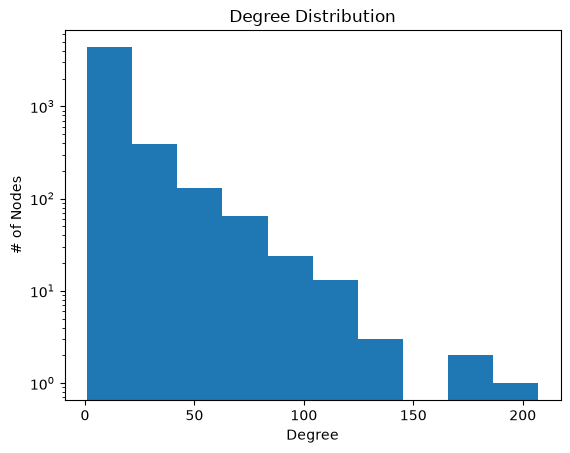

In [11]:
plt.hist(degrees)
plt.yscale('log') # I added this line because original plot was difficult to read when I plotted it the first time
plt.xlabel("Degree") 
plt.ylabel("# of Nodes")
plt.title("Degree Distribution")
plt.show()

# 8. Add a markdown cell and discuss what you observe by looking at the generated degree distribution

Most observations have relatively low degree values, while only a small number of nodes have much higher degree values.

In [12]:
deg = np.array(degrees)

# Number of nodes in each degree range
rangos = [(1, 2), (3, 5), (6, 10), (11, 20), (21, 50), (51, 100), (101, None)]

for lo, hi in rangos:
    n = ((deg >= lo) & (deg <= hi)).sum() if hi else (deg >= lo).sum()
    etiqueta = f"{lo}-{hi}" if hi else f"{lo}+"
    print("degree %-7s %4d nodes (%4.1f%%)" % (etiqueta + ":", n, 100 * n / len(deg)))


degree 1-2:    2488 nodes (49.8%)
degree 3-5:     845 nodes (16.9%)
degree 6-10:    543 nodes (10.9%)
degree 11-20:   473 nodes ( 9.5%)
degree 21-50:   475 nodes ( 9.5%)
degree 51-100:  155 nodes ( 3.1%)
degree 101+:     21 nodes ( 0.4%)


With this visualization I check that most of the nodes have just 1-2 connections, so, probably it means that this nodes are a close path (death end), probably due to BFS subgraph but I must check that, while we have nodes (>30%) with a bigger degree (+6) that works as reference points to connect all the network. Getting this way a short diameter for a big subgraph.

It is related with the method I selected for my assignment (BFS), that shows certain level of depth for this subgraph, so, actually is not a good description for the entire graph, just for this subgraph.

# 9. Calculate the average degree of a node.

In [13]:
degrees = [degree for node, degree in G_sample.degree()] # Same line from past cells
average_degree = np.mean(degrees)
print("Average degree:", average_degree)

Average degree: 9.1344


# 10. Add a markdown cell. In your own words, explain what the obtained average degree of a node mean in the context of this dataset?

It means that on average each node of my dataset-subgraph has 9 coonnections with others nodes, but... analyzing the last cells I saw that a big amount of nodes (majority) has just 1-2 connections (50%), so, maybe the average is not a good measure for this question, due to some ranges of nodes >50 degree (probably outliers, to prove it we need a boxplot, so, its just a suspicion) that directly affect the average. Also, if we look the histogram we can appreciate that we dont have a normal distribution, so, average is not a representative measure. For this case I would use the median.

# 11. Calculate the average shortest path length between any two nodes.

In [14]:
# Average shortest path length for my subgraph
average_shortest_path = nx.average_shortest_path_length(G_sample)
print("Average shortest path length:", average_shortest_path)

Average shortest path length: 3.934033846769354


In [15]:
# The full graph is not connected (1339 components) and computing the exact
# average shortest path length would require a BFS from each of the148k nodes.
# Instead I estimate it using a random sample of source nodes
gcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()

random.seed(7)
n_sources = 60
sources = random.sample(list(gcc.nodes()), n_sources)

total = count = 0
for u in sources:
    for v, d in nx.single_source_shortest_path_length(gcc, u).items():
        if u != v:
            total += d
            count += 1

estimated_aspl = total / count
print("Giant component: %d nodes, %d edges" % (gcc.number_of_nodes(), gcc.number_of_edges()))
print("Estimated average shortest path length (sample of %d source nodes): %.2f" % (n_sources, estimated_aspl))


Giant component: 148386 nodes, 296770 edges
Estimated average shortest path length (sample of 60 source nodes): 6.15


# 12. Add a markdown cell. In your own words, explain what the obtained value of the average shortest path length means in the context of this dataset.

It means that if I want to connect two nodes within this dataset network finding the shortest path, the average length would be 4 edges. As I checked, the diameter for this subgraph is 6 edges, so, an average of 4 it's a reasonable measure, taking into account the amount of nodes with a death end in this dataset. 

All of this show my subgraph node actually are relatively close to each other although it's a big network of 5000 nodes. But... again, i'm pretty sure this is due the BFS I selected for my assignment. This method explore it throw levels and that's why I have this scenario with an average of 4 (3.93) edges for the shortest paths between 2 nodes. Also, I calculated the average shortest path for a bigger sample of the entire graph, confirming that the BFS has a big influence with this aswer main point

# 13. Plot the distribution of shortest path length.

In [16]:
import collections
path_lengths = collections.Counter()

for node in G_sample.nodes(): # Iterate over each node in the sampled graph
    distances = nx.single_source_shortest_path_length(G_sample, node) # Calculate shortest path lengths from the current node to all other nodes
    for target, d in distances.items(): # Iterate over the distances from the source node to all other nodes
        if node != target: # Avoid counting the distance from a node to itself
            path_lengths[d] += 1


In [17]:
path_lengths

Counter({4: 12854666, 5: 5564842, 3: 5506438, 2: 904244, 6: 119138, 1: 45672})

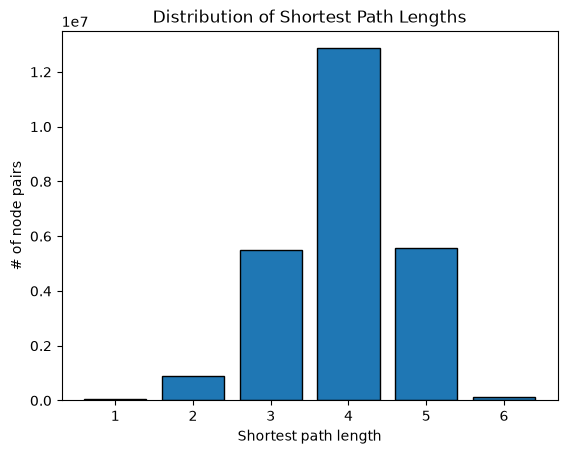

In [20]:
lengths = sorted(path_lengths) # [1, 2, 3, 4, 5, 6]
counts  = [path_lengths[d] for d in lengths] # How many node pairs are at each distance

plt.bar(lengths, counts, edgecolor='black')
plt.xlabel("Shortest path length")
plt.ylabel("# of node pairs")
plt.title("Distribution of Shortest Path Lengths")
plt.show()


# 14. Add a markdown cell and explain what you observe in this histogram.

This histogram shows the distribution of shortest path distances between the nodes of G_sample. Each bar indicates how many node pairs have a specific minimum distance. In this case, a distance of 4 is the most frequent as we verified in the last cells, meaning that the majority of node pairs are connected by a shortest path of approximately 4 hops.

I also see a good distribution of the shortest paths, similar to a normal distribution, so, it confirms that average its a good representative measure for this problem

# 15. Calculate the edge density of this graph

In [21]:
edge_density = nx.density(G_sample)
print("Edge density:", edge_density)

Edge density: 0.001827245449089818


# 16. Add a markdown cell and answer the following question. What can we conclude about this graph considering its edge density? 

As we checked in the questions related with average degree, this graph has a lot of nodes between the range of 1-5 degree (66%) in a subgraph with 5000 nodes. Edge density measures the proportion of actual edges in the graph compared to the maximum number of possible edges it could have.. So, having a very low degree confirms that the edge density would be extremely low. BFS for my case gave me a good density zone within the subgraph but also we have death end nodes that affect this measure, taking into account that good connected nodes has small proportion of connections compared with total of posibilities.

# 17. Calculate the global clustering coefficient of this graph

In [22]:
global_clustering = nx.transitivity(G_sample)
print("Global clustering coefficient:", global_clustering)

Global clustering coefficient: 0.14423629114782613


# 18. Add a markdown cell and answer the following question. What can we conclude about this graph considering its global clustering coefficient?

For this graph it indicates that it has a global clustering coefficient of 0.14, which means that there is a certain tendency for connected nodes to form triplets or triangles, compared to the expectations of the edge density, that show a graph with a minium proportion of connections compared with the total. 

At the beginning when I analyzed degree of nodes it appears as a very isolated subgraph with some specific paths to reach each node. Then with the last cells I discovered a high degree zone in the center of the graph with nodes with a higher edge density. So, it makes sense thinking these triplets are more concentrated in this zone of the subgraph. Here I found the concept of small world that fit perfect with my subgraph, short shortest paths and a big clustering. In this case I consider clustering is very high because the edge density its considerably smaller.

For our dataset context it has a high level of interactions between artists, revealing that there exist some close communities within the network, especially in this part of the subgraph.

That's why the diameter is just 6 edges. Because the center of the graph contains a lot of shortcuts that allow us to reach each node of the network coming from this center zone, which represents some artists with a big influence.

# 19. Calculate the number of connected components in the graph

In [24]:
connected_components = nx.number_connected_components(G_sample)
print("N of connected components:", connected_components)


N of connected components: 1


The analyzed subgraph has 1 connected component. This means that all 5000 of its nodes are connected either directly or indirectly by a path.

This result is consistent with the selection process using BFS, as this method explores nodes reachable from a starting node. However, it does not necessarily represent the entire original graph, which contains multiple disconnected components.

# 20. Load the node attribute file and display the first few rows of the dataset

### Nodes

In [25]:
path_2 = '/Users/andresarias/Documents/FAU/SocialNetworks_BigData/Assignment_1/data/nodes.csv'
nodes = pd.read_csv(path_2, sep=',')
nodes.head(5)

,spotify_id,name,followers,popularity,genres,chart_hits
0,48WvrUGoijadXXCsGocwM4,Byklubben,1738.0,24,"['nordic house', 'russelater']",['no (3)']
1,4lDiJcOJ2GLCK6p9q5BgfK,Kontra K,1999676.0,72,"['christlicher rap', 'german hip hop']","['at (44)', 'de (111)', 'lu (22)', 'ch (31)', ..."
2,652XIvIBNGg3C0KIGEJWit,Maxim,34596.0,36,[],['de (1)']
3,3dXC1YPbnQPsfHPVkm1ipj,Christopher Martin,249233.0,52,"['dancehall', 'lovers rock', 'modern reggae', ...","['at (1)', 'de (1)']"
4,74terC9ol9zMo8rfzhSOiG,Jakob Hellman,21193.0,39,"['classic swedish pop', 'norrbotten indie', 's...",['se (6)']


# 21. Plot a histogram of the followers variable. 

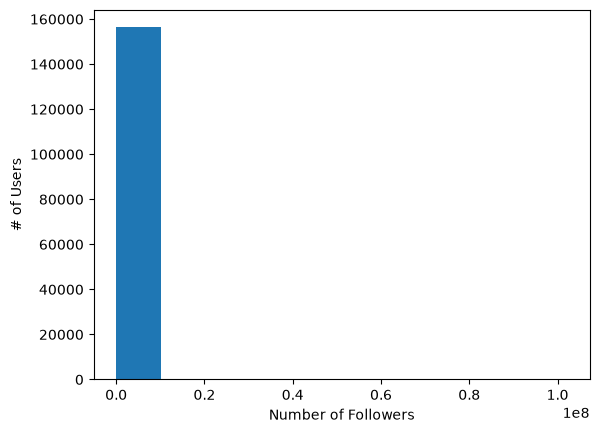

In [27]:
plt.hist(nodes['followers'])
plt.xlabel("Number of Followers")
plt.ylabel("# of Users")
plt.show()

This histo is not useful. So hard to read and practically don't say nothing

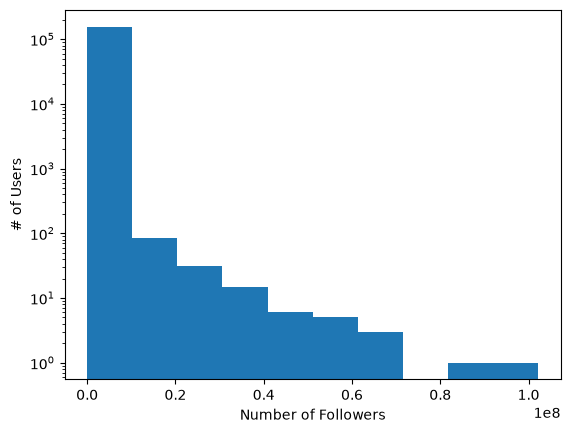

In [28]:
plt.hist(nodes['followers'])
plt.yscale('log') # I added this line because original plot was difficult to read when I plotted it the first time
plt.xlabel("Degree") 
plt.xlabel("Number of Followers")
plt.ylabel("# of Users")
plt.show()

# 22. Add a markdown cell and describe the distribution. Is it symmetric, skewed, and does it contain outliers? 